In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# load in CCSA data
ccsa_data = pd.read_csv('CCSA.csv')
# ccsa_data.head()

In [68]:
# standardize the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
ccsa_data_scaled = scaler.fit_transform(ccsa_data['CCSA'].values.reshape(-1, 1))

In [69]:
# c) Assign observations from 2000 to 2015, inclusive, to the Training partition. The Testing
# partition will contain the remaining ten years of observations. Because not all months have a fifth
# week, further split the Training partition by month into two groups. The first group includes months
# with fifth-week counts. The second group comprises months with only four weeks of counts.
# Generate principal components for the two groups in the Training partition. How many principal
# components do you choose for each group? Also, what percentage of the total variance do the
# principal components explain in each group? Please show your work to justify your choices.
ccsa_data['Week'] = pd.to_datetime(ccsa_data['observation_date'], format='%Y-%m-%d').dt.isocalendar().week
ccsa_data['Year'] = pd.to_datetime(ccsa_data['observation_date'], format='%Y-%m-%d').dt.year
ccsa_data['Month'] = pd.to_datetime(ccsa_data['observation_date'], format='%Y-%m-%d').dt.month
ccsa_data['Week_of_Month'] = ((ccsa_data['Week'] - 1) % 5) + 1
ccsa_train = ccsa_data[(ccsa_data['Year'] >= 2000) & (ccsa_data['Year'] <= 2015)]
ccsa_test = ccsa_data[(ccsa_data['Year'] > 2015)]

ccsa_train_pivot = ccsa_train.pivot_table(index=['Year', 'Month'], columns='Week_of_Month', values='CCSA')
train_w_fifth = ccsa_train_pivot.dropna()
train_wo_fifth = ccsa_train_pivot[ccsa_train_pivot[5].isna()].drop(columns=[5]).dropna()

# ccsa_train_pivot.head()

train_wo_fifth.head()
# ccsa_test_pivot = ccsa_test.pivot_table(index=['Year', 'Month'], columns='Week_of_Month', values='CCSA')
# test_w_fifth = ccsa_test_pivot.dropna(subset=[5])
# test_wo_fifth = ccsa_test_pivot[ccsa_test_pivot[5].isna()]

Week_of_Month          1          2          3          4
Year Month                                               
2000 1         2107000.0  2108500.0  2061000.0  2164000.0
     8         2096000.0  2109000.0  2145000.0  2119000.0
2001 1         2357000.0  2367000.0  2419000.0  2440000.0
     8         3079000.0  3125000.0  3113000.0  3163000.0
2002 1         3587000.0  3500000.0  3557000.0  3558000.0

Explained variance ratios for months with fifth week:
[9.97511968e-01 1.07964099e-03 7.29877266e-04 3.76350887e-04
 3.02162617e-04]


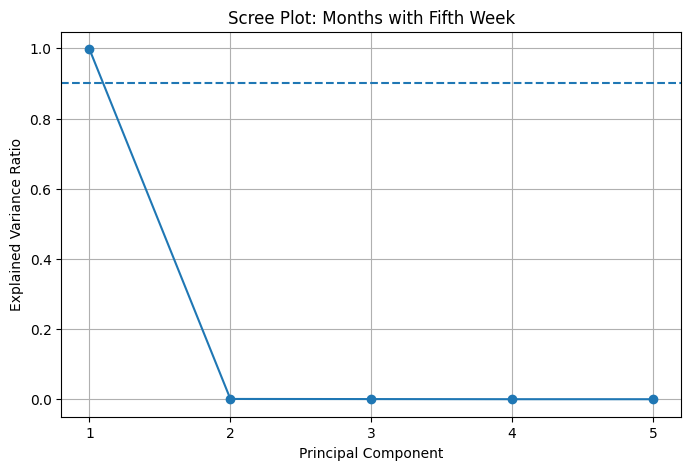

In [70]:
pca_5 = PCA()
pca_5.fit(train_w_fifth)

print("Explained variance ratios for months with fifth week:")
print(pca_5.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca_5.explained_variance_ratio_) + 1),
    pca_5.explained_variance_ratio_,
    marker='o'
)
plt.axhline(0.9, linestyle='--', label='90% Variance')
plt.title('Scree Plot: Months with Fifth Week')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(1, 6))
plt.grid()
plt.show()

Explained variance ratios for months without fifth week:
[9.98416754e-01 1.07738764e-03 2.65291238e-04 2.40567482e-04]


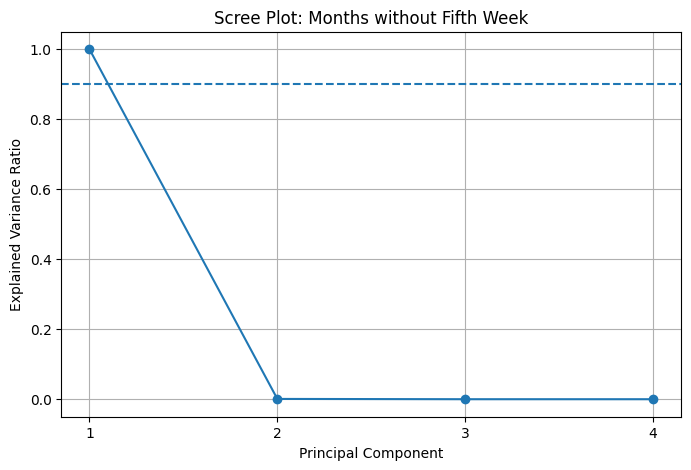

In [71]:
pca_4 = PCA()
pca_4.fit(train_wo_fifth)

print("Explained variance ratios for months without fifth week:")
print(pca_4.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca_4.explained_variance_ratio_) + 1),
    pca_4.explained_variance_ratio_,
    marker='o'
)
plt.axhline(0.9, linestyle='--', label='90% Variance')
plt.title('Scree Plot: Months without Fifth Week')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(1, 5))
plt.grid()
plt.show()

In [72]:
pca_5.n_components = 2
pca_5.fit(train_w_fifth)

pca_4.n_components = 2
pca_4.fit(train_wo_fifth)

,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [73]:
# create groups in testing partition
ccsa_test_pivot = ccsa_test.pivot_table(index=['Year', 'Month'], columns='Week_of_Month', values='CCSA')
test_w_fifth = ccsa_test_pivot.dropna()
test_wo_fifth = ccsa_test_pivot[ccsa_test_pivot[5].isna()].drop(columns=[5]).dropna()

# transform testing data using trained pca models
test_w_fifth_pca = pca_5.transform(test_w_fifth)
test_wo_fifth_pca = pca_4.transform(test_wo_fifth)

In [74]:
test_w_fifth_pca_df = pd.DataFrame(test_w_fifth_pca, index=test_w_fifth.index, columns=[f'PC1', 'PC2'])
test_wo_fifth_pca_df = pd.DataFrame(test_wo_fifth_pca, index=test_wo_fifth.index, columns=[f'PC1', 'PC2'])
test_pca_concat = pd.concat([test_w_fifth_pca_df, test_wo_fifth_pca_df]).sort_index()

test_pca_concat.head()

PC1           PC2
Year Month                            
2016 1     -1.988562e+06    264.646845
     4     -2.336780e+06   6267.913840
     7     -2.368980e+06  -6445.540074
     8     -2.113244e+06  23146.076054
     10    -2.507596e+06 -18622.167944

In [75]:
# print the variances of the principal components applied to the Testing partition
print("Variances of the principal components in the Testing partition:")
print(test_pca_concat.var())

Variances of the principal components in the Testing partition:
PC1    4.959071e+13
PC2    7.223843e+10
dtype: float64


### Question 2

In [76]:
# load in the data
retail_data = pd.read_csv('Retail_Theft_20260109 (1).csv')
retail_data.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,14071609,JK100791,12/31/2025 09:15:00 PM,009XX W IRVING PARK RD,860,THEFT,RETAIL THEFT,DRUG STORE,False,False,...,46.0,6.0,6,1169204.0,1926746.0,2025,2026 Jan 08 03:46:48 PM,41.954507,-87.653373,POINT (-87.653372774 41.954507152)
1,14071604,JK100442,12/31/2025 07:21:00 PM,032XX N CLARK ST,860,THEFT,RETAIL THEFT,DEPARTMENT STORE,False,False,...,44.0,6.0,6,1169868.0,1921628.0,2025,2026 Jan 08 03:46:48 PM,41.940449,-87.651082,POINT (-87.651081589 41.94044868)
2,14071238,JK100579,12/31/2025 07:07:00 PM,012XX W 79TH ST,860,THEFT,RETAIL THEFT,DRUG STORE,False,False,...,17.0,71.0,6,1169539.0,1852401.0,2025,2026 Jan 08 03:46:48 PM,41.750491,-87.654302,POINT (-87.654302474 41.750490827)
3,14071589,JK100443,12/31/2025 05:43:00 PM,027XX N CLYBOURN AVE,860,THEFT,RETAIL THEFT,SMALL RETAIL STORE,False,False,...,32.0,7.0,6,1162872.0,1918208.0,2025,2026 Jan 08 03:46:48 PM,41.931214,-87.676890,POINT (-87.676890454 41.93121391)
4,14070595,JJ540418,12/31/2025 04:46:00 PM,032XX N CLARK ST,860,THEFT,RETAIL THEFT,DEPARTMENT STORE,True,False,...,44.0,6.0,6,1169868.0,1921628.0,2025,2026 Jan 08 03:46:48 PM,41.940449,-87.651082,POINT (-87.651081589 41.94044868)


In [77]:
# data types
retail_data.dtypes

ID                        int64
Case Number              object
Date                     object
Block                    object
IUCR                      int64
Primary Type             object
Description              object
Location Description     object
Arrest                     bool
Domestic                   bool
Beat                      int64
District                  int64
Ward                    float64
Community Area          float64
FBI Code                  int64
X Coordinate            float64
Y Coordinate            float64
Year                      int64
Updated On               object
Latitude                float64
Longitude               float64
Location                 object
dtype: object

In [78]:
# print missing values
print(retail_data.isnull().sum())

ID                        0
Case Number               0
Date                      0
Block                     0
IUCR                      0
Primary Type              0
Description               0
Location Description      3
Arrest                    0
Domestic                  0
Beat                      0
District                  0
Ward                     12
Community Area           48
FBI Code                  0
X Coordinate            948
Y Coordinate            948
Year                      0
Updated On                0
Latitude                948
Longitude               948
Location                948
dtype: int64


In [79]:
from matplotlib.ticker import AutoLocator, MultipleLocator
from mlxtend.frequent_patterns import (apriori, association_rules)
from mlxtend.preprocessing import TransactionEncoder

In [80]:
# load in the data
retail_data = pd.read_csv('Retail_Theft_20260109 (1).csv')

# Create the dataset as described in the assignment
# I used chatGPT to generate this code using the following prompt:
# can you write code to make a dataset following this description and only keeping useful features: For illustrative purposes, we use only observations where the retail theft occurred in 2025 (i.e., Year is 2025) and at the following locations: DEPARTMENT STORE, SMALL RETAIL STORE, GROCERY FOOD STORE, DRUG STORE, CONVENIENCE STORE, GAS STATION, TAVERN/LIQUOR STORE, COMMERCIAL / BUSINESS OFFICE, RESTAURANT, APPLIANCE STORE, WAREHOUSE, and TAVERN / LIQUOR STORE. This selection yielded 13,282 observations for analysis, with an overall arrest rate of approximately 30.65%. We extracted the month and hour of the incident from the Date field. Because the Chicago Police patrol unit operates in three shifts, called Police Watch, we will map each hour to a Police Watch as follows. Police Watch is ‘First’ if the hour is 5 to 11, ‘First -> Second’ if the hour is 12, ‘Second’ if the hour is 13 to 19, ‘Second -> Third’ if the hour is 20, ‘Third’ if the hour is 21 to 23 and 0 to 3, and ‘Third -> First’ if the hour is 4
import pandas as pd

# Ensure Date is datetime
retail_data['Date'] = pd.to_datetime(retail_data['Date'])

# Retail theft filter
df_rt = retail_data[
    (retail_data['Primary Type'] == 'THEFT') &
    (retail_data['Description'].str.contains('RETAIL', case=False, na=False)) &
    (retail_data['Year'] == 2025)
].copy()

# Allowed locations
allowed_locations = [
    'DEPARTMENT STORE',
    'SMALL RETAIL STORE',
    'GROCERY FOOD STORE',
    'DRUG STORE',
    'CONVENIENCE STORE',
    'GAS STATION',
    'TAVERN/LIQUOR STORE',
    'COMMERCIAL / BUSINESS OFFICE',
    'RESTAURANT',
    'APPLIANCE STORE',
    'WAREHOUSE',
    'TAVERN / LIQUOR STORE'
]

df_rt = df_rt[
    df_rt['Location Description'].isin(allowed_locations)
]

df_rt['Month'] = df_rt['Date'].dt.month
df_rt['Hour'] = df_rt['Date'].dt.hour

def police_watch(hour):
    if 5 <= hour <= 11:
        return 'First'
    elif hour == 12:
        return 'First->Second'
    elif 13 <= hour <= 19:
        return 'Second'
    elif hour == 20:
        return 'Second->Third'
    elif hour in [21, 22, 23, 0, 1, 2, 3]:
        return 'Third'
    elif hour == 4:
        return 'Third->First'
    else:
        return 'Unknown'

df_rt['Police Watch'] = df_rt['Hour'].apply(police_watch)

df_final = df_rt[[
    'Arrest',
    'Domestic',
    'Location Description',
    'Month',
    'Police Watch',
    'District',
    'Beat'
]].copy()

df_final = df_final.dropna()

/var/folders/hf/8cmwp2xj1kl_vshvblvw8shw0000gn/T/ipykernel_86524/2825251150.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  retail_data['Date'] = pd.to_datetime(retail_data['Date'])


In [81]:
# We first train our association rules using the 862 observations from Beats #111, #112, and #113
# combined. Subsequently, we will test our association rules using the 410 observations from Beat #1834.
df_train = df_final[df_final['Beat'].isin([111, 112, 113])].copy()
df_test = df_final[df_final['Beat'] == 1834].copy()

In [82]:
print(len(df_train), len(df_test))

862 410


In [83]:
# a) (10 points) Discover association rules with a minimum Support of five incidents and a minimum Lift
# of one. We only want association rules whose Consequents contain a particular 1-item set. That 1-
# item set is either {Arrest is True} or {Arrest is False}. After removing redundant rules, how many
# association rules remain with {Arrest is True} in the consequent? How many association rules remain
# with {Arrest is False} in the consequent?

# preprocess data for association rule mining
df_train['Arrest'] = df_train['Arrest'].astype(str)
transactions = df_train.apply(lambda row: [f"{col}={row[col]}" for col in df_train.columns], axis=1).tolist()  

# encode transactions into indicator format
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
retail_encoded = pd.DataFrame(te_ary, columns=te.columns_)

# find frequent itemsets
prop_support = 5/retail_encoded.shape[0]
frequent_itemsets = apriori(retail_encoded, min_support=prop_support, use_colnames=True)

# generate association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# filter rules for Arrest=True and Arrest=False in the consequent
rules_arrest_true = rules[rules['consequents'].apply(lambda x: 'Arrest=True' in x)]
rules_arrest_false = rules[rules['consequents'].apply(lambda x: 'Arrest=False' in x)]

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/mlxtend/frequent_patterns/association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


In [84]:
def remove_redundant_rules(rules):
    # sort rules by length of antecedents and consequents
    rules = rules.copy()
    rules['rule_length'] = rules['antecedents'].apply(lambda x: len(x)) + rules['consequents'].apply(lambda x: len(x))
    rules = rules.sort_values(by='rule_length')

    non_redundant_rules = []
    for i, rule in rules.iterrows():
        is_redundant = False
        for j in non_redundant_rules:
            if j['antecedents'].issubset(rule['antecedents']) and j['consequents'].issubset(rule['consequents']):
                is_redundant = True
                break
        if not is_redundant:
            non_redundant_rules.append(rule)
    
    return pd.DataFrame(non_redundant_rules).drop(columns=['rule_length'])

# Simplify rules by removing redundant rules with lower confidence
# Class code
# def simplify_rule (rule_df):
#     rule_sorted = rule_df.sort_values(by = 'confidence', ascending = False)
#     all_index = rule_sorted.index
#     n_rule = rule_sorted.shape[0]
#     index_to_drop = []
#     for i in range(n_rule):
#         s1 = rule_sorted.iloc[i]['antecedents']
#         for j in range(i+1,n_rule):
#             s2 = rule_sorted.iloc[j]['antecedents']
#             if (s1.issuperset(s2)):
#                 index_to_drop.append(all_index[j])
#     simplified_rule_df = rule_sorted.drop(index_to_drop)
#     return simplified_rule_df

# remove redundant rules
rules_arrest_true_nr = remove_redundant_rules(rules_arrest_true)
rules_arrest_false_nr = remove_redundant_rules(rules_arrest_false)


# print the number of non-redundant rules
print(f"Number of non-redundant rules with Arrest=True in the consequent: {len(rules_arrest_true_nr)}")
print(f"Number of non-redundant rules with Arrest=False in the consequent: {len(rules_arrest_false_nr)}")

Number of non-redundant rules with Arrest=True in the consequent: 51
Number of non-redundant rules with Arrest=False in the consequent: 86


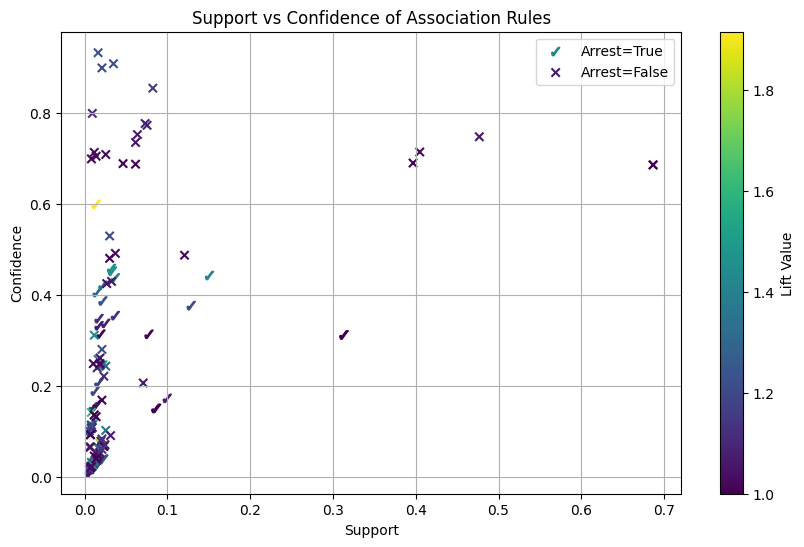

In [85]:
# b) (10 points) Plot the Support values against the Confidence values of the association rules of interest
# in Part (b). Use the checkmark ('$\u2713$') if an arrest is made and the 'x' marker if no arrest is
# made. Also, color-code the markers according to the lift values in the rules.

plt.figure(figsize=(10, 6))
scatter_true = plt.scatter(
    rules_arrest_true_nr['support'],
    rules_arrest_true_nr['confidence'],
    c=rules_arrest_true_nr['lift'],
    cmap='viridis',
    marker='$\u2713$',
    label='Arrest=True'
)
scatter_false = plt.scatter(
    rules_arrest_false_nr['support'],
    rules_arrest_false_nr['confidence'],
    c=rules_arrest_false_nr['lift'],
    cmap='viridis',
    marker='x',
    label='Arrest=False'
)
plt.colorbar(scatter_true, label='Lift Value')
plt.title('Support vs Confidence of Association Rules')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.legend()
plt.grid()
plt.show()

In [86]:
test_transactions = df_test.apply(
    lambda row: [f"{col}={row[col]}" for col in df_test.columns],
    axis=1
).tolist()

predictions = []

all_rules = pd.concat([rules_arrest_true_nr, rules_arrest_false_nr])

for transaction in test_transactions:
    matched_rules = []

    for _, rule in all_rules.iterrows():
        if rule['antecedents'].issubset(set(transaction)):
            matched_rules.append(rule)

    if matched_rules:
        best_rule = max(matched_rules, key=lambda x: x['confidence'])
        if 'Arrest=True' in best_rule['consequents']:
            predictions.append(1)
        else:
            predictions.append(0)
    else:
        predictions.append(None)

actual = df_test['Arrest'].astype(int).tolist()

tp = sum(1 for p, a in zip(predictions, actual) if p == 1 and a == 1)
tn = sum(1 for p, a in zip(predictions, actual) if p == 0 and a == 0)
fp = sum(1 for p, a in zip(predictions, actual) if p == 1 and a == 0)
fn = sum(1 for p, a in zip(predictions, actual) if p == 0 and a == 1)

confusion_matrix = pd.DataFrame(
    [[tp, fp],
     [fn, tn]],
    index=['Actual Arrest', 'Actual No Arrest'],
    columns=['Predicted Arrest', 'Predicted No Arrest']
)

print(confusion_matrix)

                  Predicted Arrest  Predicted No Arrest
Actual Arrest                    0                    0
Actual No Arrest               118                  292


In [87]:
valid = [(p, a) for p, a in zip(predictions, actual) if p is not None]

accuracy = sum(1 for p, a in valid if p == a) / len(valid)
print("Accuracy:", accuracy)


Accuracy: 0.7121951219512195


In [88]:
no_prediction_rate = predictions.count(None) / len(predictions)
print("No prediction rate:", no_prediction_rate)

No prediction rate: 0.0


In [89]:
true_rule_matches = 0
for transaction in test_transactions:
    for _, rule in rules_arrest_true_nr.iterrows():
        if rule['antecedents'].issubset(set(transaction)):
            true_rule_matches += 1

print("Arrest=True rule matches:", true_rule_matches)


Arrest=True rule matches: 4906


In [90]:
rules_arrest_true_nr = rules_arrest_true_nr.reset_index(drop=True)
rules_arrest_false_nr = rules_arrest_false_nr.reset_index(drop=True)

rules_arrest_true_nr['rule_id'] = ['T' + str(i+1) for i in range(len(rules_arrest_true_nr))]
rules_arrest_false_nr['rule_id'] = ['F' + str(i+1) for i in range(len(rules_arrest_false_nr))]

from collections import defaultdict

invocation_counts = defaultdict(int)

for transaction in test_transactions:
    for _, rule in rules_arrest_true_nr.iterrows():
        if rule['antecedents'].issubset(set(transaction)):
            invocation_counts[rule['rule_id']] += 1

    for _, rule in rules_arrest_false_nr.iterrows():
        if rule['antecedents'].issubset(set(transaction)):
            invocation_counts[rule['rule_id']] += 1

rules_arrest_true_nr['invocations'] = rules_arrest_true_nr['rule_id'].map(invocation_counts).fillna(0).astype(int)
rules_arrest_false_nr['invocations'] = rules_arrest_false_nr['rule_id'].map(invocation_counts).fillna(0).astype(int)


In [91]:
top3_arrest = rules_arrest_true_nr.sort_values(
    by='invocations',
    ascending=False
).head(3)


In [92]:
top3_no_arrest = rules_arrest_false_nr.sort_values(
    by='invocations',
    ascending=False
).head(3)


In [93]:
cols_to_show = [
    'rule_id',
    'invocations',
    'antecedents',
    'confidence',
    'lift'
]

print("Top 3 Arrest=True Rules")
display(top3_arrest[cols_to_show])

print("Top 3 Arrest=False Rules")
display(top3_no_arrest[cols_to_show])


Top 3 Arrest=True Rules


,rule_id,invocations,antecedents,confidence,lift
11,T12,410,(Domestic=False),0.313225,1.000000
18,T19,231,(Police Watch=Second),0.016162,1.160943
35,T36,231,(Police Watch=Second),0.151515,1.004662


Top 3 Arrest=False Rules


,rule_id,invocations,antecedents,confidence,lift
11,F12,410,(Domestic=False),0.686775,1.000000
7,F8,231,(Police Watch=Second),0.690909,1.006020
9,F10,173,(Location Description=DEPARTMENT STORE),0.715164,1.041337
